# Clase 7: Ejercicios
## AMLO vs Sheinbaum — Comentarios de YouTube

In [2]:
%%capture
pip install google-api-python-client transformers torch pandas matplotlib

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from google.colab import userdata
from googleapiclient.discovery import build
from transformers import pipeline

YOUTUBE_API_KEY = userdata.get('YOUTUBE_API_KEY')
VIDEO_AMLO      = "ZTU-y38SBk8"
VIDEO_SHEINBAUM = "dVjnggFAmJc"

youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)
print("Cargando modelo...")
clasificador = pipeline("zero-shot-classification",
                        model="facebook/bart-large-mnli", device=0)
print("Listo ✓")

Cargando modelo...


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Listo ✓


## Parte 1 — Estadísticas (diccionarios)

In [6]:
def obtener_stats(video_id):
    resp = youtube.videos().list(part='snippet,statistics', id=video_id).execute()
    v    = resp['items'][0]
    return {
        'titulo'     : v['snippet']['title'],
        'fecha'      : v['snippet']['publishedAt'][:10],
        'vistas'     : int(v['statistics'].get('viewCount', 0)),
        'likes'      : int(v['statistics'].get('likeCount', 0)),
        'comentarios': int(v['statistics'].get('commentCount', 0))
    }

stats_amlo      = obtener_stats(VIDEO_AMLO)
stats_sheinbaum = obtener_stats(VIDEO_SHEINBAUM)

**Ejercicio 1.** `stats_amlo` y `stats_sheinbaum` son diccionarios. Crea un tercer diccionario llamado `comparacion` que tenga las siguientes claves, calculadas a partir de los dos diccionarios:

- `'engagement_amlo'`: likes / vistas * 100
- `'engagement_sheinbaum'`: ídem para Sheinbaum
- `'mas_vistas'`: el nombre del video con más vistas (`'AMLO'` o `'Sheinbaum'`)
- `'diferencia_vistas'`: la diferencia absoluta en número de vistas

Luego imprime cada clave y valor con un for loop.

In [7]:
comparacion = {
    'engagement_amlo'      : stats_amlo['likes'] / stats_amlo['vistas'] * 100,
    'engagement_sheinbaum' : stats_sheinbaum['likes'] / stats_sheinbaum['vistas'] * 100,
    'mas_vistas'           : 'AMLO' if stats_amlo ['vistas'] > stats_sheinbaum ['vistas'] else 'Sheinbaum',
    'diferencia_vistas'    : abs(stats_amlo['vistas'] - stats_sheinbaum['vistas'])
}

for clave, valor in comparacion.items():
    print(f"{clave}: {valor}")

engagement_amlo: 8.247391800533771
engagement_sheinbaum: 8.466429918327771
mas_vistas: Sheinbaum
diferencia_vistas: 2371


## Parte 2 — Descargar y clasificar

In [13]:
def descargar_y_limpiar(video_id, nombre, max_comentarios=150):
    comentarios = []
    page_token  = None
    while len(comentarios) < max_comentarios:
        resp = youtube.commentThreads().list(
            part='snippet', videoId=video_id,
            maxResults=min(100, max_comentarios - len(comentarios)),
            order='relevance', pageToken=page_token
        ).execute()
        for item in resp['items']:
            s = item['snippet']['topLevelComment']['snippet']
            comentarios.append({'texto': s['textDisplay'],
                                'likes': s['likeCount'],
                                'respuestas': item['snippet']['totalReplyCount']})
        page_token = resp.get('nextPageToken')
        if not page_token: break
    df = pd.DataFrame(comentarios)
    df['texto_limpio'] = (df['texto']
        .str.replace('', ' ', regex=False)
        .str.replace('&', '&', regex=False)
        .str.strip())
    df = df[df['texto_limpio'].str.len() >= 15].reset_index(drop=True)
    df['video'] = nombre
    print(f"{nombre}: {len(df)} comentarios ✓")
    return df

CATEGORIAS = [
    "support or praise for the government",
    "criticism or opposition to the government",
    "humor or sarcasm",
    "spam or irrelevant"
]

def clasificar(df):
    cats, scores = [], []
    for i, texto in enumerate(df['texto_limpio']):
        r = clasificador(texto, CATEGORIAS)
        cats.append(r['labels'][0])
        scores.append(r['scores'][0])
        if (i+1) % 50 == 0: print(f"  {i+1}/{len(df)}...")
    df = df.copy()
    df['categoria'] = cats
    df['score']     = scores
    return df

df_amlo      = clasificar(descargar_y_limpiar(VIDEO_AMLO,      'AMLO'))
df_sheinbaum = clasificar(descargar_y_limpiar(VIDEO_SHEINBAUM, 'Sheinbaum'))
df_total     = pd.concat([df_amlo, df_sheinbaum], ignore_index=True)
print("Listo ✓")

AMLO: 150 comentarios ✓
  50/150...
  100/150...
  150/150...
Sheinbaum: 148 comentarios ✓
  50/148...
  100/148...
Listo ✓


## Parte 3 — Listas y tuplas

**Ejercicio 2.** Usando list comprehensions, crea:

- `textos_amlo`: lista con todos los textos limpios del video de AMLO
- `likes_amlo`: lista con todos los likes del video de AMLO
- `pares_amlo`: lista de **tuplas** `(texto, likes)` para cada comentario de AMLO, ordenada de mayor a menor likes

Imprime los 3 primeros elementos de `pares_amlo`.

In [14]:
# filtramos el DataFrame de AMLO
amlo = df_total[df_total['video'] == 'AMLO']

textos_amlo = [texto for texto in amlo['texto_limpio']]
likes_amlo  = [likes for likes in amlo['likes']]

# zip() une dos listas en pares — sorted() ordena, key= indica por qué criterio
# reverse=True para ordenar de mayor a menor
pares_amlo = sorted(
    [(texto, likes) for texto, likes in zip(textos_amlo, likes_amlo)],
    key=lambda par: par[1],   # par[1] = los likes (segundo elemento de la tupla)
    reverse=True
)

print("Top 3 comentarios de AMLO por likes:")
for texto, likes in pares_amlo[:3]:
    print(f"  [{likes} likes] {texto[:80]}")

Top 3 comentarios de AMLO por likes:
  [320 likes] P e r i o d i s t a   d e   t v   a z t e c a   q u i e r e s   r e s p e t o   
  [255 likes] R e p o r t e r o s   d e   M é x i c o .     R e s p e t e n   a l   p u e b l 
  [222 likes] D i j e r o n   q u e   a l   a ñ o   l a s   “ M a ñ a n e r a s ”   y a   i b 


**Ejercicio 3.** Crea un diccionario llamado `resumen` donde cada clave es el nombre del video (`'AMLO'`, `'Sheinbaum'`) y cada valor es una tupla con:

`(número de comentarios, likes promedio, categoría más frecuente)`

Luego itera sobre el diccionario e imprime cada video con su resumen.

In [15]:
resumen = {}

for nombre in ['AMLO', 'Sheinbaum']:
    grupo = df_total[df_total['video'] == nombre]

    n_comentarios   = len(grupo)   # número de filas
    likes_promedio  = round(grupo['likes'].mean(), 1)   # promedio de la columna likes, redondeado a 1 decimal
    cat_frecuente   = grupo['categoria'].value_counts().index[0]   # categoría más frecuente: usa .value_counts().index[0]

    resumen[nombre] = (n_comentarios, likes_promedio, cat_frecuente)

for video, (n, lk, cat) in resumen.items():
    print(f"{video}: {n} comentarios | {lk} likes promedio | categoría más frecuente: {cat}")

AMLO: 150 comentarios | 37.2 likes promedio | categoría más frecuente: humor or sarcasm
Sheinbaum: 148 comentarios | 6.5 likes promedio | categoría más frecuente: humor or sarcasm


## Parte 4 — Visualización

**Ejercicio 4.** Completa el código para hacer la gráfica comparativa.

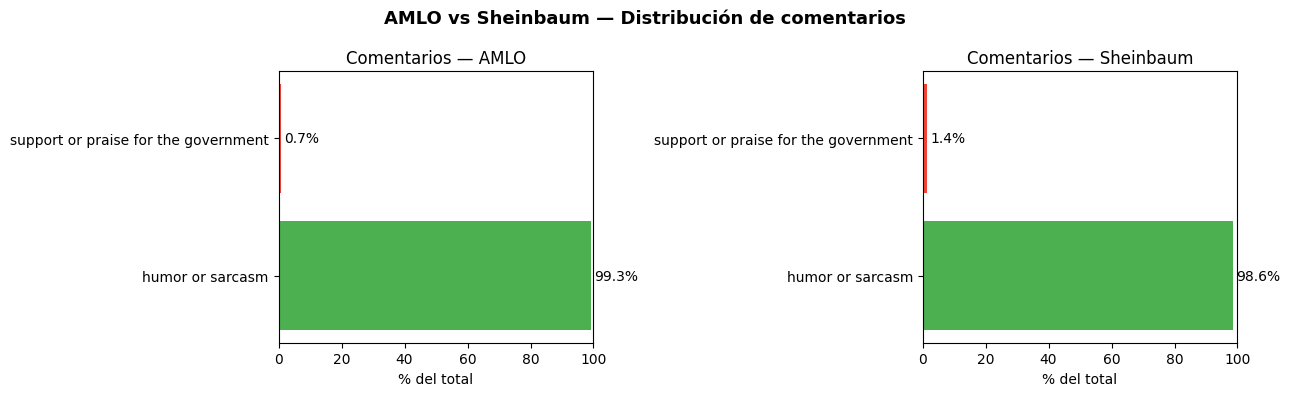

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colores = ['#4CAF50', '#F44336', '#FF9800', '#9E9E9E']

for ax, (nombre, grupo) in zip(axes, df_total.groupby('video')):
    pct = grupo['categoria'].value_counts() / len(grupo) * 100

    ax.barh(pct.index, pct.values, color=colores[:len(pct)])

    ax.set_title(f'Comentarios — {nombre}', fontsize=12)
    ax.set_xlabel('% del total')
    ax.set_xlim(0, 100)
    for i, v in enumerate(pct.values):
        ax.text(v + 1, i, f'{v:.1f}%', va='center')

fig.suptitle('AMLO vs Sheinbaum — Distribución de comentarios',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 5.** Top 3 comentarios más likeados de cada video.

In [17]:
for nombre in ['AMLO', 'Sheinbaum']:
    print(f"\nTop 3 — {nombre}")

    top3 = df_total[df_total['video'] == nombre].sort_values(by='likes', ascending=False).head(3)

    for i, f in top3.iterrows():
        print(f"  [{f['likes']} likes | {f['categoria']}] {f['texto_limpio'][:80]}")


Top 3 — AMLO
  [320 likes | humor or sarcasm] P e r i o d i s t a   d e   t v   a z t e c a   q u i e r e s   r e s p e t o   
  [255 likes | humor or sarcasm] R e p o r t e r o s   d e   M é x i c o .     R e s p e t e n   a l   p u e b l 
  [222 likes | humor or sarcasm] D i j e r o n   q u e   a l   a ñ o   l a s   “ M a ñ a n e r a s ”   y a   i b 

Top 3 — Sheinbaum
  [50 likes | humor or sarcasm] I n d i s c u t i b l e m e n   N u e s t r a   P r e s i d e n t a   S i e m p 
  [45 likes | humor or sarcasm] B u e n o s   d í a s   a   n u e s t r a   P r e s i d e n t a   C l a u d i a 
  [39 likes | humor or sarcasm] E X E L E N T E   P R E S I D E N T A   👍 🏾
